This model will be the basis for the ingredient estimation based on the overhead RGB image. This changes from a regression task to a classification. The base model used will be the DINOv2 Base in the hope of not getting a naming issue once they are combined.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import os
import pandas as pd
import numpy as np

Configuration

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")

METADATA_CSV = Path(
    "/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/"
    "dish_carb_mass_ingredients_split_metadata.csv"
)

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

Loading metadata and creating paths for images

In [ ]:
df = pd.read_csv(METADATA_CSV)

print("Loaded file:", METADATA_CSV)
print("Shape before processing:", df.shape)
print("Columns:", df.columns.tolist()[:30], "...")
display(df.head())

Loaded file: /content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_ingredients_split_metadata.csv
Shape before processing: (3262, 205)
Columns: ['dish_id', 'total_mass', 'total_carb', 'split', 'source_cafe', 'num_ingredients', 'ingredient_list_str', 'ingr_almonds', 'ingr_apple', 'ingr_artichokes', 'ingr_arugula', 'ingr_asparagus', 'ingr_avocado', 'ingr_baby_carrots', 'ingr_bacon', 'ingr_bagels', 'ingr_banana_with_peel', 'ingr_basil', 'ingr_beef', 'ingr_beets', 'ingr_bell_peppers', 'ingr_berries', 'ingr_black_beans', 'ingr_blackberries', 'ingr_blue_cheese', 'ingr_blueberries', 'ingr_bok_choy', 'ingr_bread', 'ingr_broccoli', 'ingr_brown_rice'] ...


,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,...,ingr_wheat_berry,ingr_wheat_bread,ingr_white_beans,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini
0,dish_1556575327,152.0,10.618,test,cafe1,3,brussels_sprouts|celery|olives,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,dish_1557861216,1.0,0.000,test,cafe1,1,plate_only,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,dish_1557862345,63.0,0.000,test,cafe1,1,chicken,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,dish_1557862696,77.0,3.850,test,cafe1,1,cauliflower,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,dish_1557862738,118.0,0.000,test,cafe1,1,steak,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
required_cols = ["dish_id", "split", "source_cafe"]
missing_cols = [c for c in required_cols if c not in df.columns]

if len(missing_cols) > 0:
    raise ValueError(f"Missing required columns: {missing_cols}")

ingredient_cols = [c for c in df.columns if c.startswith("ingr_")]

if len(ingredient_cols) == 0:
    raise ValueError("No ingredient columns found. Expected columns starting with 'ingr_'.")

print("Number of ingredient columns:", len(ingredient_cols))
print("First 20 ingredient columns:", ingredient_cols[:20])

Number of ingredient columns: 198
First 20 ingredient columns: ['ingr_almonds', 'ingr_apple', 'ingr_artichokes', 'ingr_arugula', 'ingr_asparagus', 'ingr_avocado', 'ingr_baby_carrots', 'ingr_bacon', 'ingr_bagels', 'ingr_banana_with_peel', 'ingr_basil', 'ingr_beef', 'ingr_beets', 'ingr_bell_peppers', 'ingr_berries', 'ingr_black_beans', 'ingr_blackberries', 'ingr_blue_cheese', 'ingr_blueberries', 'ingr_bok_choy']


In [ ]:
df["dish_id"] = df["dish_id"].astype(str).str.strip()

df["rgb_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / str(d) / "overhead" / "rgb.png")
)

df["rgb_exists"] = df["rgb_path"].apply(lambda p: Path(p).exists())

print("Missing RGB images:", (~df["rgb_exists"]).sum())

Missing RGB images: 0


Filtering invalid RGB paths

In [ ]:
def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except Exception:
        return -1

df["rgb_size"] = df["rgb_path"].apply(file_size_or_minus1)

print("Empty RGB files:", (df["rgb_size"] <= 0).sum())

df = df[
    (df["rgb_exists"]) &
    (df["rgb_size"] > 0)
].copy()

print("\nRemaining samples after RGB filtering:")
print(df["split"].value_counts(dropna=False))
print("Total remaining:", len(df))
display(df.head())

Empty RGB files: 0

Remaining samples after RGB filtering:
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total remaining: 3262


,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,...,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini,rgb_path,rgb_exists,rgb_size
0,dish_1556575327,152.0,10.618,test,cafe1,3,brussels_sprouts|celery|olives,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,548259
1,dish_1557861216,1.0,0.000,test,cafe1,1,plate_only,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,353804
2,dish_1557862345,63.0,0.000,test,cafe1,1,chicken,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,407501
3,dish_1557862696,77.0,3.850,test,cafe1,1,cauliflower,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,391780
4,dish_1557862738,118.0,0.000,test,cafe1,1,steak,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412017


In [ ]:
for col in ingredient_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(np.float32)

label_cardinality = df[ingredient_cols].sum(axis=1)

print("Ingredient labels per dish:")
print(label_cardinality.describe())

print("\nDishes with no positive ingredient labels:", int((label_cardinality == 0).sum()))
print("Dishes with at least one ingredient:", int((label_cardinality > 0).sum()))

Ingredient labels per dish:
count    3262.000000
mean        7.312998
std         6.943369
min         1.000000
25%         1.000000
50%         4.000000
75%        12.000000
max        34.000000
dtype: float64

Dishes with no positive ingredient labels: 0
Dishes with at least one ingredient: 3262


Splitting dataset

In [ ]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df   = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df  = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


Saving prepared CSV files

In [ ]:
train_csv = PREP_DIR / "train_ingredient_classifier.csv"
val_csv   = PREP_DIR / "val_ingredient_classifier.csv"
test_csv  = PREP_DIR / "test_ingredient_classifier.csv"
full_csv  = PREP_DIR / "full_ingredient_classifier.csv"
ingredient_cols_txt = PREP_DIR / "ingredient_columns.txt"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)
df.to_csv(full_csv, index=False)

with open(ingredient_cols_txt, "w") as f:
    for col in ingredient_cols:
        f.write(col + "\n")

print("Saved:")
print(train_csv)
print(val_csv)
print(test_csv)
print(full_csv)
print(ingredient_cols_txt)

Saved:
/content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier/prep_files/train_ingredient_classifier.csv
/content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier/prep_files/val_ingredient_classifier.csv
/content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier/prep_files/test_ingredient_classifier.csv
/content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier/prep_files/full_ingredient_classifier.csv
/content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier/prep_files/ingredient_columns.txt


SWITCH TO GPU FOR MODEL TRAINING

In [ ]:
!pip install -q keras-hub huggingface_hub scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import keras_hub

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    hamming_loss,
    classification_report
)

Configuration

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

STAGE1_EPOCHS = 100
STAGE2_EPOCHS = 200

STAGE1_LR = 2e-4
STAGE2_LR = 5e-6

BACKBONE_PRESET = "dinov2_base"

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"

train_csv = PREP_DIR / "train_ingredient_classifier.csv"
val_csv   = PREP_DIR / "val_ingredient_classifier.csv"
test_csv  = PREP_DIR / "test_ingredient_classifier.csv"
ingredient_cols_txt = PREP_DIR / "ingredient_columns.txt"

Loading dataset

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

with open(ingredient_cols_txt, "r") as f:
    ingredient_cols = [line.strip() for line in f if line.strip()]

NUM_INGREDIENTS = len(ingredient_cols)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))
print("NUM_INGREDIENTS:", NUM_INGREDIENTS)

display(train_df.head())

Train: 2421
Val:   334
Test:  507
NUM_INGREDIENTS: 198


,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,...,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini,rgb_path,rgb_exists,rgb_size
0,dish_1556572657,36.0,2.268,train,cafe1,1,olives,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412129
1,dish_1556573514,23.0,1.219,train,cafe1,1,mixed_greens,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,432908
2,dish_1556575014,62.0,3.906,train,cafe1,1,olives,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,409854
3,dish_1556575083,64.0,5.760,train,cafe1,1,brussels_sprouts,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,396942
4,dish_1556575124,28.0,0.952,train,cafe1,1,celery,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,404314


In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=IMG_HEIGHT,
        target_width=IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_and_multilabel(rgb_path, label_vector):
    rgb = load_rgb_image(rgb_path)
    label_vector = tf.cast(label_vector, tf.float32)
    return {"rgb_input": rgb}, label_vector


def make_dataset(dataframe, ingredient_cols, batch_size=16, shuffle=False):
    rgb_paths = dataframe["rgb_path"].values
    labels = dataframe[ingredient_cols].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_rgb_and_multilabel, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [ ]:
train_dataset = make_dataset(train_df, ingredient_cols, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, ingredient_cols, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, ingredient_cols, batch_size=BATCH_SIZE, shuffle=False)

for batch_inputs, batch_labels in train_dataset.take(1):
    print("RGB batch shape:", batch_inputs["rgb_input"].shape)
    print("Labels shape:   ", batch_labels.shape)

RGB batch shape: (16, 224, 224, 3)
Labels shape:    (16, 198)


Checking for correct load in

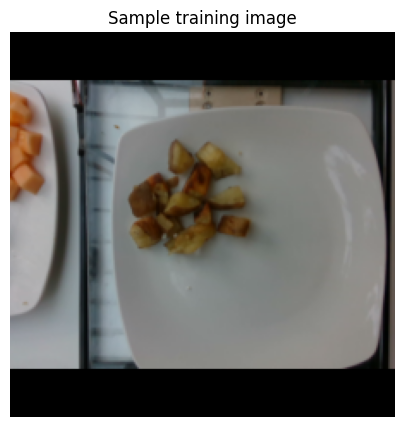

Positive ingredients: ['ingr_olive_oil', 'ingr_sweet_potato']
Number of positive ingredients: 2


In [ ]:
for batch_inputs, batch_labels in train_dataset.take(1):
    sample_img = batch_inputs["rgb_input"][0].numpy().astype("uint8")
    sample_lbl = batch_labels[0].numpy()

    plt.figure(figsize=(5, 5))
    plt.imshow(sample_img)
    plt.title("Sample training image")
    plt.axis("off")
    plt.show()

    positive_ingredients = [ingredient_cols[i] for i, v in enumerate(sample_lbl) if v > 0.5]
    print("Positive ingredients:", positive_ingredients[:20])
    print("Number of positive ingredients:", len(positive_ingredients))

Loading DINOv2 Base model

In [ ]:
image_converter = keras_hub.layers.ImageConverter.from_preset(
    BACKBONE_PRESET,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
)

backbone = keras_hub.models.Backbone.from_preset(
    BACKBONE_PRESET,
    image_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
)

backbone.trainable = False

print("Using preset:", BACKBONE_PRESET)
print("Image size:", (IMG_HEIGHT, IMG_WIDTH))

100%|██████████| 781/781 [00:00<00:00, 1.73MB/s]


100%|██████████| 977/977 [00:00<00:00, 2.33MB/s]


100%|██████████| 335M/335M [00:31<00:00, 11.0MB/s]


Using preset: dinov2_base
Image size: (224, 224)


In [ ]:
def extract_backbone_tensor(x):
    if isinstance(x, dict):
        preferred_keys = [
            "sequence_output",
            "pooled_output",
            "encoder_output",
            "token_embeddings",
            "hidden_states"
        ]
        for key in preferred_keys:
            if key in x:
                return x[key]
        return list(x.values())[0]
    return x

Model architecture

In [ ]:
rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

x = image_converter(rgb_input)
x = backbone(x)
x = extract_backbone_tensor(x)

if len(x.shape) == 3:
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D(name="token_pool")(x)
else:
    x = layers.LayerNormalization()(x)
    x = layers.Flatten()(x)

x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu", name="dense_128")(x)
x = layers.Dropout(0.2)(x)

output = layers.Dense(
    NUM_INGREDIENTS,
    activation="sigmoid",
    name="ingredient_output"
)(x)

model = keras.Model(
    inputs={"rgb_input": rgb_input},
    outputs=output,
    name="rgb_only_dinov2_base_ingredient_classifier"
)

model.summary()

Model: "rgb_only_dinov2_base_ingredient_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_image_converter          │ (None, 224, 224, 3)    │             0 │
│ (DINOV2ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_backbone                 │ (None, 257, 768)       │    86,777,856 │
│ (DINOV2Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 257, 768)       │         1,536 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_pool                      │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ingredient_output (Dense)       │ (None, 198)            │        25,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,034,694 (332.01 MB)

 Trainable params: 256,838 (1003.27 KB)

 Non-trainable params: 86,777,856 (331.03 MB)

In [ ]:
auc_macro = keras.metrics.AUC(
    multi_label=True,
    num_labels=NUM_INGREDIENTS,
    curve="ROC",
    name="auc_macro"
)

binary_acc = keras.metrics.BinaryAccuracy(name="binary_accuracy", threshold=0.5)
precision_m = keras.metrics.Precision(name="precision", thresholds=0.5)
recall_m = keras.metrics.Recall(name="recall", thresholds=0.5)

Stage 1 training (frozen backbone)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss="binary_crossentropy",
    metrics=[
        binary_acc,
        precision_m,
        recall_m,
        auc_macro
    ],
    jit_compile=False
)

In [ ]:
stage1_best_path = OUTPUT_DIR / "best_model_stage1.weights.h5"

stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(stage1_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=35,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE1_EPOCHS,
    callbacks=stage1_callbacks
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - auc_macro: 0.4472 - binary_accuracy: 0.7526 - loss: 0.4666 - precision: 0.0416 - recall: 0.2431
Epoch 1: val_loss improved from None to 0.13899, saving model to /content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier/best_model_stage1.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier/best_model_stage1.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - auc_macro: 0.5044 - binary_accuracy: 0.8729 - loss: 0.2963 - precision: 0.0560 - recall: 0.1568 - val_auc_macro: 0.4668 - val_binary_accuracy: 0.9596 - val_loss: 0.1390 - val_precision: 0.8678 - val_recall: 0.0539 - learning_rate: 2.0000e-04
Epoch 2/100
151/152 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - auc_macro: 0.5352 - binary_accuracy: 0.9621 - loss: 0.1389 - precision: 0.4492 - recall: 0.0968
Epoch 2: val_loss improved from 0.13899 to 0.12977, saving model to /content/drive/MyDrive/Speciale/M

Evaluating stage 1

In [ ]:
model.load_weights(str(stage1_best_path))

stage1_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 1 test results:")
for k, v in stage1_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - auc_macro: 0.7096 - binary_accuracy: 0.9729 - loss: 0.0765 - precision: 0.7129 - recall: 0.4044
Stage 1 test results:
auc_macro: 0.7096
binary_accuracy: 0.9729
loss: 0.0765
precision: 0.7129
recall: 0.4044


Stage 2 training (30% of backbone unfrozen)

In [ ]:
model.load_weights(str(stage1_best_path))

backbone.trainable = True

num_layers = len(backbone.layers)
freeze_until = int(num_layers * 0.70)

for i, layer in enumerate(backbone.layers):
    layer.trainable = (i >= freeze_until)

print(f"Total backbone layers: {num_layers}")
print(f"Frozen layers:         {freeze_until}")
print(f"Trainable layers:      {num_layers - freeze_until}")

trainable_count = 0
frozen_count = 0
for layer in backbone.layers:
    if layer.trainable:
        trainable_count += 1
    else:
        frozen_count += 1

print("Backbone trainable layers:", trainable_count)
print("Backbone frozen layers:   ", frozen_count)

Total backbone layers: 4
Frozen layers:         2
Trainable layers:      2
Backbone trainable layers: 2
Backbone frozen layers:    2


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="binary_accuracy", threshold=0.5),
        keras.metrics.Precision(name="precision", thresholds=0.5),
        keras.metrics.Recall(name="recall", thresholds=0.5),
        keras.metrics.AUC(
            multi_label=True,
            num_labels=NUM_INGREDIENTS,
            curve="ROC",
            name="auc_macro"
        )
    ],
    jit_compile=False
)

In [ ]:
stage2_best_path = OUTPUT_DIR / "best_model_stage2.weights.h5"

stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(stage2_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=75,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=50,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE2_EPOCHS,
    callbacks=stage2_callbacks
)

Epoch 1/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - auc_macro: 0.8535 - binary_accuracy: 0.9746 - loss: 0.0654 - precision: 0.7452 - recall: 0.4879
Epoch 1: val_loss improved from None to 0.10460, saving model to /content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier/best_model_stage2.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier/best_model_stage2.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 105s 456ms/step - auc_macro: 0.9142 - binary_accuracy: 0.9760 - loss: 0.0618 - precision: 0.7547 - recall: 0.5079 - val_auc_macro: 0.6168 - val_binary_accuracy: 0.9631 - val_loss: 0.1046 - val_precision: 0.6081 - val_recall: 0.3606 - learning_rate: 5.0000e-06
Epoch 2/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - auc_macro: 0.8673 - binary_accuracy: 0.9788 - loss: 0.0546 - precision: 0.7880 - recall: 0.5577
Epoch 2: val_loss improved from 0.10460 to 0.09823, saving model to /content/drive/

Evaluating stage 2

In [ ]:
model.load_weights(str(stage2_best_path))

stage2_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 2 test results:")
for k, v in stage2_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - auc_macro: 0.7135 - binary_accuracy: 0.9744 - loss: 0.0714 - precision: 0.6933 - recall: 0.5043
Stage 2 test results:
auc_macro: 0.7135
binary_accuracy: 0.9744
loss: 0.0714
precision: 0.6933
recall: 0.5043


Plotting training and validation curves

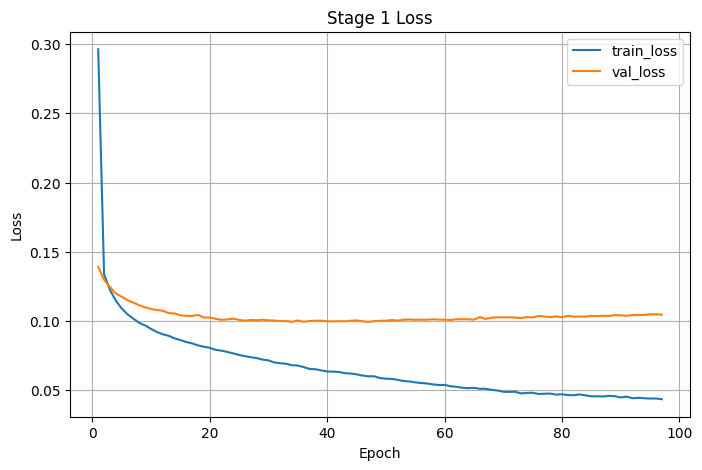

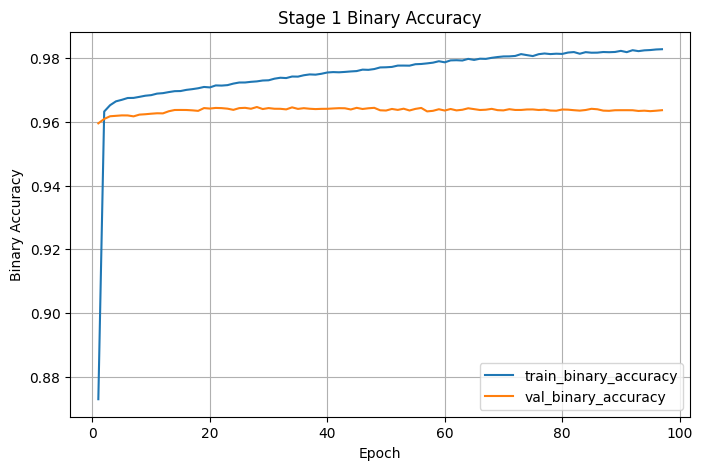

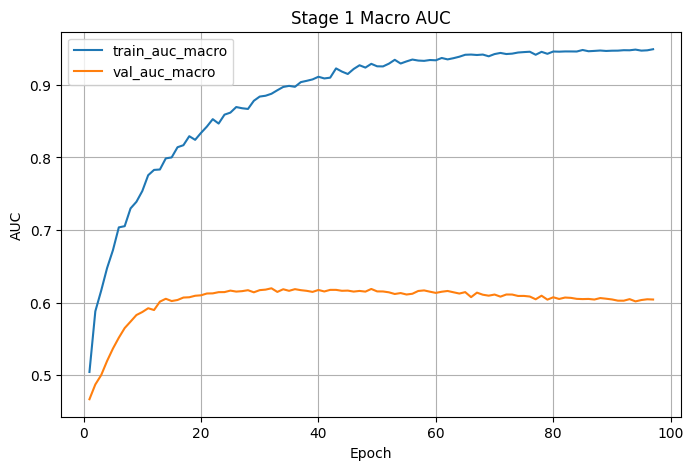

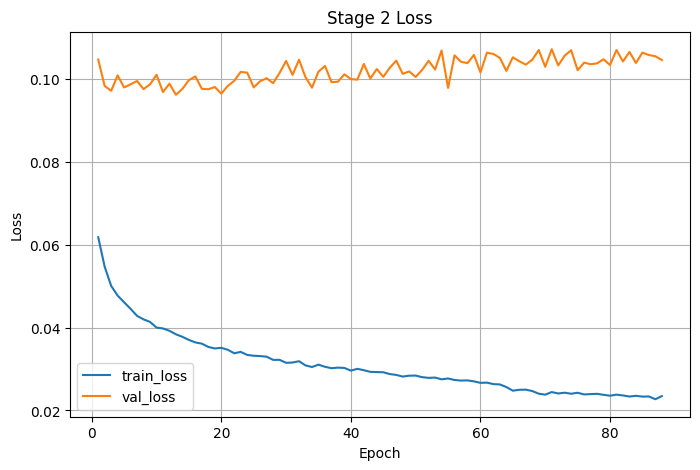

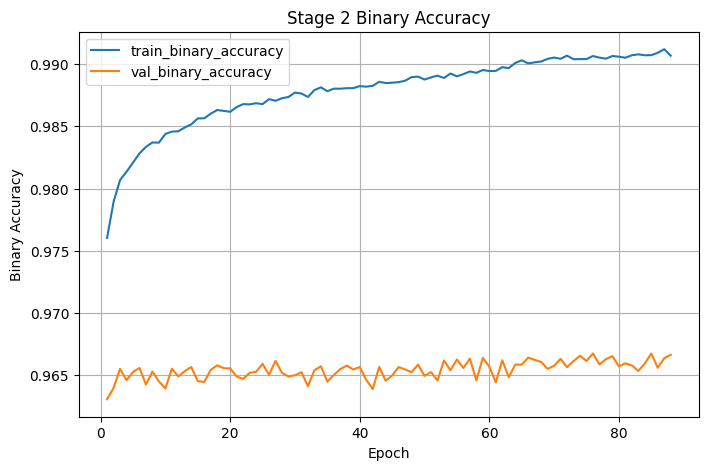

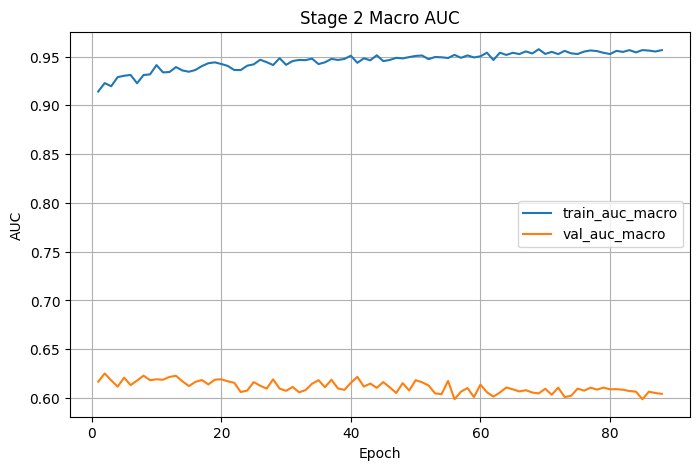

In [ ]:
def plot_history(history, title_prefix=""):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    if "binary_accuracy" in hist:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, hist["binary_accuracy"], label="train_binary_accuracy")
        plt.plot(epochs, hist["val_binary_accuracy"], label="val_binary_accuracy")
        plt.title(f"{title_prefix} Binary Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Binary Accuracy")
        plt.legend()
        plt.grid(True)
        plt.show()

    if "auc_macro" in hist:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, hist["auc_macro"], label="train_auc_macro")
        plt.plot(epochs, hist["val_auc_macro"], label="val_auc_macro")
        plt.title(f"{title_prefix} Macro AUC")
        plt.xlabel("Epoch")
        plt.ylabel("AUC")
        plt.legend()
        plt.grid(True)
        plt.show()

plot_history(history_stage1, "Stage 1")
plot_history(history_stage2, "Stage 2")

Comparing stage 1 and stage 2

In [ ]:
comparison_df = pd.DataFrame([
    {"stage": "stage1", **stage1_test_results},
    {"stage": "stage2", **stage2_test_results},
])

display(comparison_df)
comparison_df.to_csv(OUTPUT_DIR / "stage_comparison.csv", index=False)

,stage,auc_macro,binary_accuracy,loss,precision,recall
0,stage1,0.709633,0.972944,0.076502,0.712949,0.404356
1,stage2,0.713478,0.974359,0.071410,0.693282,0.504328


In [ ]:
model.load_weights(str(stage2_best_path))

test_pred_probs = model.predict(test_dataset, verbose=1)
val_pred_probs  = model.predict(validation_dataset, verbose=1)
train_pred_probs = model.predict(train_dataset, verbose=1)

print("test_pred_probs shape:", test_pred_probs.shape)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)


31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 164ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step
152/152 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step
test_pred_probs shape: (507, 198)


In [ ]:
THRESHOLD = 0.5

y_train_true = train_df[ingredient_cols].values.astype(np.int32)
y_val_true   = val_df[ingredient_cols].values.astype(np.int32)
y_test_true  = test_df[ingredient_cols].values.astype(np.int32)

y_train_pred = (train_pred_probs >= THRESHOLD).astype(np.int32)
y_val_pred   = (val_pred_probs >= THRESHOLD).astype(np.int32)
y_test_pred  = (test_pred_probs >= THRESHOLD).astype(np.int32)


def exact_match_ratio(y_true, y_pred):
    return np.mean(np.all(y_true == y_pred, axis=1))


def multilabel_metrics(y_true, y_pred, y_prob, split_name="test"):
    metrics = {
        "split": split_name,
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "micro_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "micro_recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "hamming_loss": hamming_loss(y_true, y_pred),
        "exact_match_ratio": exact_match_ratio(y_true, y_pred),
        "mean_labels_true": y_true.sum(axis=1).mean(),
        "mean_labels_pred": y_pred.sum(axis=1).mean(),
    }
    return metrics


metrics_train = multilabel_metrics(y_train_true, y_train_pred, train_pred_probs, "train")
metrics_val   = multilabel_metrics(y_val_true, y_val_pred, val_pred_probs, "val")
metrics_test  = multilabel_metrics(y_test_true, y_test_pred, test_pred_probs, "test")

metrics_df = pd.DataFrame([metrics_train, metrics_val, metrics_test])
display(metrics_df)

metrics_df.to_csv(OUTPUT_DIR / "multilabel_metrics.csv", index=False)

,split,micro_f1,macro_f1,weighted_f1,micro_precision,macro_precision,micro_recall,macro_recall,hamming_loss,exact_match_ratio,mean_labels_true,mean_labels_pred
0,train,0.140533,0.031216,0.132858,0.150277,0.033343,0.131975,0.029952,0.058841,0.004957,7.217266,6.338290
1,val,0.526251,0.174339,0.464537,0.624939,0.249430,0.454481,0.158998,0.034658,0.125749,8.386228,6.098802
2,test,0.583899,0.230308,0.536606,0.693282,0.321381,0.504328,0.206419,0.025641,0.268245,7.063116,5.138067


Per ingredient performance

In [ ]:
ingredient_rows = []

for i, ingr in enumerate(ingredient_cols):
    y_true_i = y_test_true[:, i]
    y_pred_i = y_test_pred[:, i]

    support = int(y_true_i.sum())

    ingredient_rows.append({
        "ingredient": ingr,
        "support_test": support,
        "precision": precision_score(y_true_i, y_pred_i, zero_division=0),
        "recall": recall_score(y_true_i, y_pred_i, zero_division=0),
        "f1": f1_score(y_true_i, y_pred_i, zero_division=0),
        "predicted_positives": int(y_pred_i.sum())
    })

ingredient_report_df = pd.DataFrame(ingredient_rows).sort_values(
    by=["support_test", "f1"], ascending=[False, False]
)

display(ingredient_report_df.head(30))
ingredient_report_df.to_csv(OUTPUT_DIR / "ingredient_wise_test_report.csv", index=False)

,ingredient,support_test,precision,recall,f1,predicted_positives
115,ingr_olive_oil,223,0.868421,0.887892,0.878049,228
150,ingr_salt,197,0.902439,0.939086,0.920398,205
78,ingr_garlic,134,0.740000,0.828358,0.781690,150
184,ingr_vinegar,121,0.789062,0.834711,0.811245,128
117,ingr_onions,100,0.634615,0.660000,0.647059,104
129,ingr_pepper,97,0.570093,0.628866,0.598039,107
123,ingr_parsley,82,0.620690,0.658537,0.639053,87
99,ingr_lemon_juice,81,0.649485,0.777778,0.707865,97
111,ingr_mustard,80,0.646341,0.662500,0.654321,82
3,ingr_arugula,79,0.677419,0.531646,0.595745,62


Saving predictions

In [ ]:
def build_prediction_df(base_df, probs, preds, ingredient_cols):
    out_df = base_df[["dish_id", "rgb_path", "split"]].copy()

    for i, col in enumerate(ingredient_cols):
        out_df[f"{col}_true"] = base_df[col].values.astype(np.int32)
        out_df[f"{col}_prob"] = probs[:, i]
        out_df[f"{col}_pred"] = preds[:, i]

    out_df["num_true_ingredients"] = base_df[ingredient_cols].sum(axis=1).values
    out_df["num_pred_ingredients"] = preds.sum(axis=1)
    out_df["exact_match"] = np.all(
        base_df[ingredient_cols].values.astype(np.int32) == preds,
        axis=1
    ).astype(np.int32)

    return out_df


train_pred_df = build_prediction_df(train_df, train_pred_probs, y_train_pred, ingredient_cols)
val_pred_df   = build_prediction_df(val_df, val_pred_probs, y_val_pred, ingredient_cols)
test_pred_df  = build_prediction_df(test_df, test_pred_probs, y_test_pred, ingredient_cols)

train_pred_df.to_csv(OUTPUT_DIR / "train_predictions.csv", index=False)
val_pred_df.to_csv(OUTPUT_DIR / "val_predictions.csv", index=False)
test_pred_df.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

print("Saved prediction files.")

/tmp/ipykernel_3232/3588651064.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out_df[f"{col}_true"] = base_df[col].values.astype(np.int32)
/tmp/ipykernel_3232/3588651064.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out_df[f"{col}_prob"] = probs[:, i]
/tmp/ipykernel_3232/3588651064.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragm

Saved prediction files.


In [ ]:
def decode_positive_labels(row_true, row_pred, ingredient_cols):
    true_labels = [ingredient_cols[i] for i, v in enumerate(row_true) if v == 1]
    pred_labels = [ingredient_cols[i] for i, v in enumerate(row_pred) if v == 1]
    return true_labels, pred_labels

sample_indices = list(range(min(10, len(test_df))))

for idx in sample_indices:
    row = test_df.iloc[idx]
    true_vec = y_test_true[idx]
    pred_vec = y_test_pred[idx]

    true_labels, pred_labels = decode_positive_labels(true_vec, pred_vec, ingredient_cols)

    print("=" * 80)
    print("Dish ID:", row["dish_id"])
    print("True ingredients:", true_labels)
    print("Pred ingredients:", pred_labels)

Dish ID: dish_1556575327
True ingredients: ['ingr_brussels_sprouts', 'ingr_celery', 'ingr_olives']
Pred ingredients: ['ingr_brussels_sprouts', 'ingr_celery', 'ingr_olives']
Dish ID: dish_1557861216
True ingredients: ['ingr_plate_only']
Pred ingredients: []
Dish ID: dish_1557862345
True ingredients: ['ingr_chicken']
Pred ingredients: []
Dish ID: dish_1557862696
True ingredients: ['ingr_cauliflower']
Pred ingredients: []
Dish ID: dish_1557862738
True ingredients: ['ingr_steak']
Pred ingredients: []
Dish ID: dish_1557862783
True ingredients: ['ingr_cauliflower', 'ingr_chicken', 'ingr_steak']
Pred ingredients: ['ingr_cauliflower']
Dish ID: dish_1557936555
True ingredients: ['ingr_eggs']
Pred ingredients: ['ingr_scrambled_eggs']
Dish ID: dish_1557936599
True ingredients: ['ingr_broccoli']
Pred ingredients: ['ingr_broccoli']
Dish ID: dish_1557936645
True ingredients: ['ingr_strawberries']
Pred ingredients: []
Dish ID: dish_1557937037
True ingredients: ['ingr_raspberries']
Pred ingredients: [

Saving final model

In [ ]:
model.load_weights(str(stage2_best_path))
model.save(OUTPUT_DIR / "final_model.keras")

print("Saved final model to:", OUTPUT_DIR / "final_model.keras")

Saved final model to: /content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier/final_model.keras


Saving summary

In [ ]:
summary = {
    "model_name": "Model_20_DINOv2_base_ingredient_classifier",
    "backbone_preset": BACKBONE_PRESET,
    "image_size": [IMG_HEIGHT, IMG_WIDTH],
    "num_ingredients": NUM_INGREDIENTS,
    "stage1_test_results": {k: float(v) for k, v in stage1_test_results.items()},
    "stage2_test_results": {k: float(v) for k, v in stage2_test_results.items()},
    "multilabel_metrics_test": {
        k: float(v) if isinstance(v, (int, float, np.floating)) else v
        for k, v in metrics_test.items()
    }
}

with open(OUTPUT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "model_name": "Model_20_DINOv2_base_ingredient_classifier",
  "backbone_preset": "dinov2_base",
  "image_size": [
    224,
    224
  ],
  "num_ingredients": 198,
  "stage1_test_results": {
    "auc_macro": 0.7096331119537354,
    "binary_accuracy": 0.972944438457489,
    "loss": 0.07650171965360641,
    "precision": 0.712949275970459,
    "recall": 0.40435633063316345
  },
  "stage2_test_results": {
    "auc_macro": 0.7134777903556824,
    "binary_accuracy": 0.9743590354919434,
    "loss": 0.07140978425741196,
    "precision": 0.6932821273803711,
    "recall": 0.5043283700942993
  },
  "multilabel_metrics_test": {
    "split": "test",
    "micro_f1": 0.5838991270611057,
    "macro_f1": 0.23030822686915392,
    "weighted_f1": 0.5366061045555337,
    "micro_precision": 0.6932821497120921,
    "macro_precision": 0.32138083624710695,
    "micro_recall": 0.5043283998882994,
    "macro_recall": 0.20641924910881432,
    "hamming_loss": 0.02564102564102564,
    "exact_match_ratio": 0.26824